In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv('../data/train.csv')
features = pd.read_csv('../data/features.csv')
stores = pd.read_csv('../data/stores.csv')

print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

train.head()

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
# Data types aur missing values check
print("=== TRAIN INFO ===")
print(train.info())
print("\n=== FEATURES INFO ===")
print(features.info())
print("\n=== MISSING VALUES IN FEATURES ===")
print(features.isnull().sum())
print("\n=== MISSING VALUES IN STORES ===")
print(stores.isnull().sum())

=== TRAIN INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB
None

=== FEATURES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   flo

In [8]:
# MarkDown columns: missing = koi promotion nahi thi, isliye 0 se fill karte hain
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
features[markdown_cols] = features[markdown_cols].fillna(0)

# CPI aur Unemployment: forward fill (pichli value se fill karna, time-series data hai)
features['CPI'] = features['CPI'].ffill()
features['Unemployment'] = features['Unemployment'].ffill()

# Verify - ab koi missing value nahi honi chahiye
print(features.isnull().sum())

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


In [9]:
# Merge train with stores and features
df = train.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

print("Merged shape:", df.shape)
df.head()

Merged shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


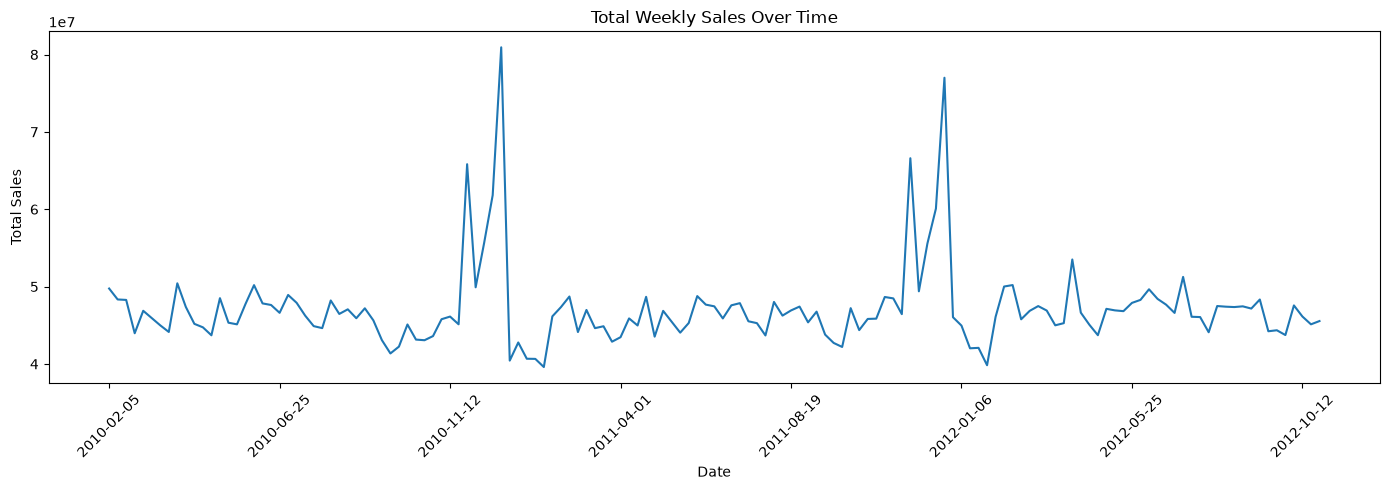

In [10]:
# 1. Overall sales trend by date
plt.figure(figsize=(14,5))
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
weekly_total.plot()
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


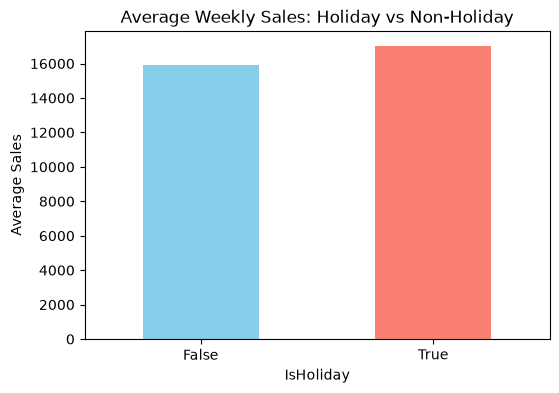

In [11]:
# Holiday vs Non-holiday average sales
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print(holiday_avg)

plt.figure(figsize=(6,4))
holiday_avg.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64


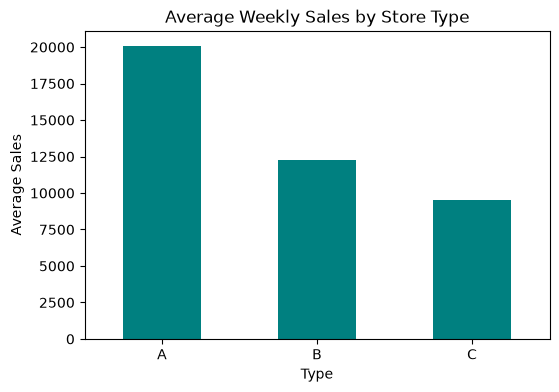

In [12]:
# Store type wise average sales
store_type_avg = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
print(store_type_avg)

plt.figure(figsize=(6,4))
store_type_avg.plot(kind='bar', color='teal')
plt.title('Average Weekly Sales by Store Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

In [13]:
# Date se features nikalna
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

# Type column ko encode karna (A=0, B=1, C=2 jaisa)
df['Type_encoded'] = df['Type'].map({'A': 0, 'B': 1, 'C': 2})

print(df[['Date', 'Year', 'Month', 'Week', 'Type', 'Type_encoded']].head())

        Date  Year  Month  Week Type  Type_encoded
0 2010-02-05  2010      2     5    A             0
1 2010-02-12  2010      2     6    A             0
2 2010-02-19  2010      2     7    A             0
3 2010-02-26  2010      2     8    A             0
4 2010-03-05  2010      3     9    A             0


In [14]:
# Features aur target select karna
features_list = ['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 
                  'Fuel_Price', 'CPI', 'Unemployment', 'Type_encoded',
                  'Year', 'Month', 'Week']

X = df[features_list]
y = df['Weekly_Sales']

# IsHoliday ko True/False se 0/1 mein convert karna
X['IsHoliday'] = X['IsHoliday'].astype(int)

# Time-based split: 2012 ka data test ke liye, baaki train
train_mask = df['Year'] < 2012
test_mask = df['Year'] == 2012

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (294132, 12)
Test size: (127438, 12)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Baseline:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Linear Regression Baseline:
MAE: 14340.31
RMSE: 21086.05


In [16]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")

Random Forest:
MAE: 2615.74
RMSE: 5342.54


In [17]:
from xgboost import XGBRegressor

# XGBoost Model
xgb_model = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost:")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")

XGBoost:
MAE: 2672.15
RMSE: 4735.44


Dept            0.276116
Size            0.249488
Type_encoded    0.130916
Month           0.101947
Week            0.062911
Store           0.060646
CPI             0.038256
IsHoliday       0.032053
Unemployment    0.022117
Year            0.011789
Temperature     0.008640
Fuel_Price      0.005120
dtype: float32


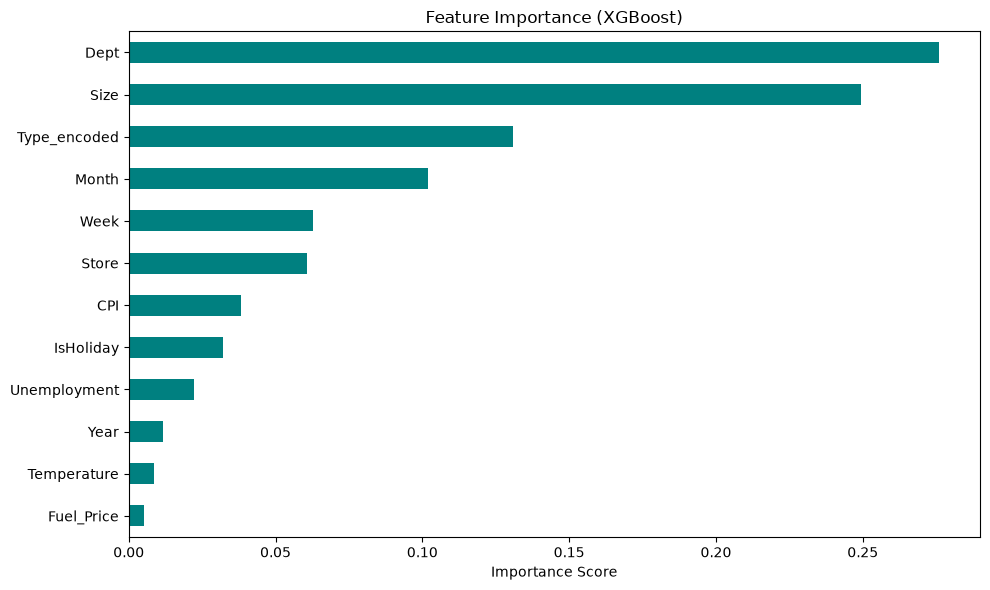

In [18]:
import matplotlib.pyplot as plt

# XGBoost built-in feature importance
importance = xgb_model.feature_importances_
feat_importance = pd.Series(importance, index=features_list).sort_values(ascending=False)

print(feat_importance)

plt.figure(figsize=(10,6))
feat_importance.plot(kind='barh', color='teal')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=15,           # 15 different combinations try karega
    scoring='neg_mean_absolute_error',
    cv=3,                # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [20]:
# Best model nikaalna
best_xgb = random_search.best_estimator_

# Predictions with tuned model
y_pred_tuned = best_xgb.predict(X_test)

# Evaluation
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("Tuned XGBoost:")
print(f"MAE: {mae_tuned:.2f}")
print(f"RMSE: {rmse_tuned:.2f}")

print("\nBest Parameters Used:")
print(random_search.best_params_)

Tuned XGBoost:
MAE: 2344.90
RMSE: 4462.47

Best Parameters Used:
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [21]:
import joblib

# Best (tuned) model save karna
joblib.dump(best_xgb, '../xgb_sales_model.pkl')
print("Model saved successfully!")

Model saved successfully!
